# 04 - feature engineering

**purpose**: extract two feature representations from preprocessed audio:

1. **log-mel-spectrograms** (128 mel bands x 251 time frames) - input to the 1d cnn
2. **mfcc + delta + delta2 vectors** (240-dim) - input to the svm baseline

**input**: `data/processed/audio/{train,val,test}/{speech,song}/Actor_XX/*.npy` (preprocessed 16khz audio clips)

**output**:

- `data/processed/X_{train,val,test}_mel.npy` - (n, 128, 251) float32
- `data/processed/X_{train,val,test}_mel_delta.npy` - (n, 384, 251) float32 (optional)
- `data/processed/X_{train,val,test}_mfcc.npy` - (n, 240) float32
- `data/processed/y_{train,val,test}.npy` - (n,) int64

per the project definition (lightweight speech emotion recognition), the main model is a 1d cnn on log-mel-spectrograms and the baseline is mfcc + svm. cross-speaker evaluation is done via fixed train/val/test splits (actors 1-19 / 20-22 / 23-24).

In [1]:
import os
os.chdir('../../')

**import libraries**. we load numpy, librosa (for feature extraction), matplotlib, and the project's feature engineering helpers from `src/utils/feature_engineering.py`.

In [2]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from src.config.config import settings
from src.utils.feature_engineering import extract_logmel, extract_mfcc_vector, get_label, extract_all_logmel, extract_all_mfcc, augment_audio

**display feature extraction parameters**. these parameters control the mel-spectrogram and mfcc extraction: 128 mel bands, 1024-point fft, 256 hop length, 40 mfcc coefficients, resulting in 251 time frames per clip.

In [3]:
print(f"SR = {settings.SAMPLE_RATE}")
print(f"N_MELS = {settings.N_MELS}")
print(f"N_FFT = {settings.N_FFT}")
print(f"HOP_LEN = {settings.HOP_LENGTH}")
print(f"N_MFCC = {settings.N_MFCC}")
print(f"N_MELS_FRAMES = {settings.N_MELS_FRAMES}")
print(f"N_MFCC_VECTOR = {settings.N_MFCC_VECTOR}")

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LEN = 256
N_MFCC = 40
N_MELS_FRAMES = 251
N_MFCC_VECTOR = 240


## Sanity check: label extraction

In [4]:
test_file = list(Path(str(settings.AUDIO_TRAIN_DIR)).rglob("*.npy"))[0]
print(f"File: {test_file.name}")

File: 03-02-01-01-01-01-01.npy


**verify label mapping**. the numeric label is mapped back to an emotion name to confirm correctness.

In [5]:
lbl = get_label(test_file)
print(f"Label: {lbl} = {settings.EMOTION_NAMES[lbl]}")

Label: 0 = neutral


## Sanity check: log-mel-spectrogram on a single sample

In [6]:
test_file = list(Path(str(settings.AUDIO_TRAIN_DIR)).rglob("*.npy"))[0]
test_audio = np.load(test_file)
mel_feat = extract_logmel(test_audio)
print(f"Log-Mel shape: {mel_feat.shape}")
print(f"Mean: {mel_feat.mean():.3f}, Std: {mel_feat.std():.3f}")
assert mel_feat.shape == (settings.N_MELS, settings.N_MELS_FRAMES), (
    f"Expected ({settings.N_MELS}, {settings.N_MELS_FRAMES}), got {mel_feat.shape}"
)

c:\Users\Admin\miniconda3\envs\speechrecog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Log-Mel shape: (128, 251)
Mean: 0.000, Std: 1.000


**plot the log-mel spectrogram**. a visual check that the mel spectrogram looks reasonable. saved to the figures directory for reference.

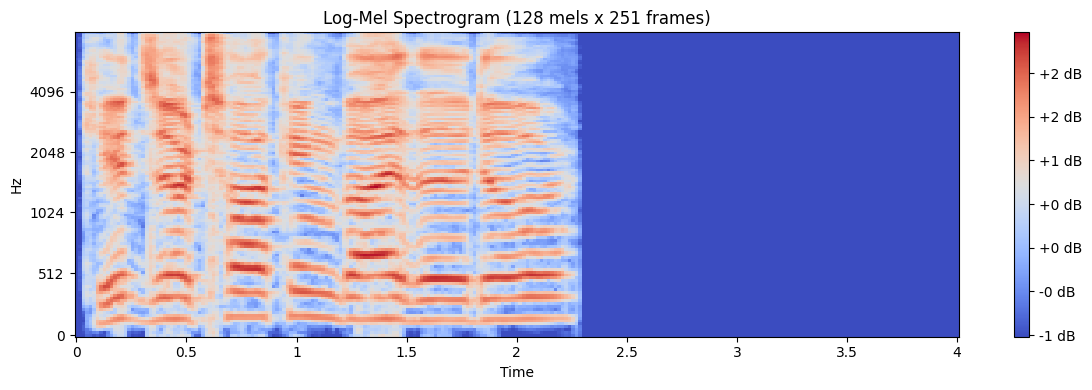

Saved fig04-mel_spectrogram.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
img = librosa.display.specshow(
    mel_feat, sr=settings.SAMPLE_RATE,
    hop_length=settings.HOP_LENGTH,
    x_axis='time', y_axis='mel', ax=ax,
)
ax.set_title(f'Log-Mel Spectrogram ({settings.N_MELS} mels x {mel_feat.shape[1]} frames)')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig04-mel_spectrogram.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved fig04-mel_spectrogram.png')

## Sanity check: MFCC vector on a single sample

In [8]:
test_file = list(Path(str(settings.AUDIO_TRAIN_DIR)).rglob("*.npy"))[0]
test_audio = np.load(test_file)
mfcc_feat = extract_mfcc_vector(test_audio)

**check mfcc shape**. confirms the vector is 240-dim as expected.

In [9]:
print(f"MFCC feature vector shape: {mfcc_feat.shape}")

MFCC feature vector shape: (240,)


**check mfcc value range**. mfcc values are not normalized like mel - they can have a wide range. this is fine since the svm will use a standardscaler later.

In [10]:
print(f"Min: {mfcc_feat.min():.3f}, Max: {mfcc_feat.max():.3f}")

Min: -255.339, Max: 244.758


**assert mfcc shape**. a programmatic guard to catch changes in feature dimensions early.

In [11]:
assert mfcc_feat.shape == (settings.N_MFCC_VECTOR,), (f"Expected ({settings.N_MFCC_VECTOR},), got {mfcc_feat.shape}")

## Batch log-mel extraction

Extracting log-mel-spectrogram features for all splits...

In [12]:
X_train_mel, y_train = extract_all_logmel(settings.AUDIO_TRAIN_DIR, "Train")
X_val_mel,   y_val   = extract_all_logmel(settings.AUDIO_VAL_DIR,   "Val")
X_test_mel,  y_test  = extract_all_logmel(settings.AUDIO_TEST_DIR,  "Test")

LogMel Test: 100%|██████████| 176/176 [00:03<00:00, 50.80it/s]


**verify batch shapes**. we check that the batched arrays have the expected dimensions for the cnn model.

In [13]:
print(f"Train: {X_train_mel.shape}, labels: {y_train.shape}")
print(f"Val:   {X_val_mel.shape}, labels: {y_val.shape}")
print(f"Test:  {X_test_mel.shape}, labels: {y_test.shape}")

Train: (1628, 128, 251), labels: (1628,)
Val:   (264, 128, 251), labels: (264,)
Test:  (176, 128, 251), labels: (176,)


## Batch MFCC extraction

Extracting MFCC features for all splits...

In [14]:
X_train_mfcc, _ = extract_all_mfcc(settings.AUDIO_TRAIN_DIR, "Train")
X_val_mfcc,   _ = extract_all_mfcc(settings.AUDIO_VAL_DIR,   "Val")
X_test_mfcc,  _ = extract_all_mfcc(settings.AUDIO_TEST_DIR,  "Test")

MFCC Test: 100%|██████████| 176/176 [00:00<00:00, 234.18it/s]


**verify mfcc shapes**. all mfcc arrays should be (n_samples, 240).

In [15]:
print(f"Train MFCC: {X_train_mfcc.shape}")
print(f"Val MFCC:   {X_val_mfcc.shape}")
print(f"Test MFCC:  {X_test_mfcc.shape}")

Train MFCC: (1628, 240)
Val MFCC:   (264, 240)
Test MFCC:  (176, 240)


## Verify no NaN in extracted features

In [16]:
for name, arr in [
    ("X_train_mel", X_train_mel), ("X_val_mel", X_val_mel), ("X_test_mel", X_test_mel),
    ("X_train_mfcc", X_train_mfcc), ("X_val_mfcc", X_val_mfcc), ("X_test_mfcc", X_test_mfcc),
]:
    n_nan = int(np.isnan(arr).sum())
    assert n_nan == 0, f"{name} has {n_nan} NaN values"
    print(f"{name:>14s} OK ({arr.shape}, dtype={arr.dtype}, nan={n_nan})")

   X_train_mel OK ((1628, 128, 251), dtype=float32, nan=0)
     X_val_mel OK ((264, 128, 251), dtype=float32, nan=0)
    X_test_mel OK ((176, 128, 251), dtype=float32, nan=0)
  X_train_mfcc OK ((1628, 240), dtype=float32, nan=0)
    X_val_mfcc OK ((264, 240), dtype=float32, nan=0)
   X_test_mfcc OK ((176, 240), dtype=float32, nan=0)


## Save features and labels

In [17]:
np.save(settings.PROCESSED_DIR / "X_train_mel.npy", X_train_mel)
np.save(settings.PROCESSED_DIR / "X_val_mel.npy",   X_val_mel)
np.save(settings.PROCESSED_DIR / "X_test_mel.npy",  X_test_mel)

**save mfcc features**. we persist the mfcc vectors for svm training (notebook 05.1).

In [18]:
np.save(settings.PROCESSED_DIR / "X_train_mfcc.npy", X_train_mfcc)
np.save(settings.PROCESSED_DIR / "X_val_mfcc.npy",   X_val_mfcc)
np.save(settings.PROCESSED_DIR / "X_test_mfcc.npy",  X_test_mfcc)

**save labels**. we save the integer label arrays for all splits.

In [19]:
np.save(settings.PROCESSED_DIR / "y_train.npy", y_train)
np.save(settings.PROCESSED_DIR / "y_val.npy",   y_val)
np.save(settings.PROCESSED_DIR / "y_test.npy",  y_test)

**print saved mel paths**. a quick confirmation of what was saved and the data shapes.

In [20]:
print(f"Saved in: {settings.PROCESSED_DIR}")
print(f"X_train_mel.npy  > {X_train_mel.shape}  (log-mel -> 1d cnn)")
print(f"X_val_mel.npy    > {X_val_mel.shape}")
print(f"X_test_mel.npy   > {X_test_mel.shape}")

Saved in: E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\processed
X_train_mel.npy  > (1628, 128, 251)  (log-mel -> 1d cnn)
X_val_mel.npy    > (264, 128, 251)
X_test_mel.npy   > (176, 128, 251)


**print the data shapes**. same confirmation for mfcc features.

In [21]:
print(f"X_train_mfcc.npy > {X_train_mfcc.shape}  (mfcc + delta -> svm)")
print(f"X_val_mfcc.npy   > {X_val_mfcc.shape}")
print(f"X_test_mfcc.npy  > {X_test_mfcc.shape}")

X_train_mfcc.npy > (1628, 240)  (mfcc + delta -> svm)
X_val_mfcc.npy   > (264, 240)
X_test_mfcc.npy  > (176, 240)


**print the data shapes**. final confirmation of label arrays.

In [22]:
print(f"y_train.npy      > {y_train.shape}")
print(f"y_val.npy        > {y_val.shape}")
print(f"y_test.npy       > {y_test.shape}")

y_train.npy      > (1628,)
y_val.npy        > (264,)
y_test.npy       > (176,)


**check class distribution**. we print the per-class sample counts to confirm the class imbalance pattern (neutral has fewer samples).

In [23]:
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (val):   {np.bincount(y_val)}")
print(f"Class distribution (test):  {np.bincount(y_test)}")

Class distribution (train): [148 296 296 296 296 296]
Class distribution (val):   [24 48 48 48 48 48]
Class distribution (test):  [16 32 32 32 32 32]


## Optional: stack delta-mel features (3 channels: mel + d1 + d2)

useful if the 1d cnn is configured to take 3 channels. enabled by setting `settings.DELTA_MEL_ORDER=2` in src/config/config.py. kept here as a separate output to keep the default input simple (1 channel).

In [24]:
if settings.DELTA_MEL_ORDER >= 1:
    print("Computing delta-mel features (stacked along channel dim)...")
    X_train_mel = np.load(settings.PROCESSED_DIR / "X_train_mel.npy")
    X_val_mel   = np.load(settings.PROCESSED_DIR / "X_val_mel.npy")
    X_test_mel  = np.load(settings.PROCESSED_DIR / "X_test_mel.npy")

    def stack_delta(mel_batch):
        d1 = librosa.feature.delta(mel_batch, axis=2)
        d2 = librosa.feature.delta(mel_batch, order=2, axis=2)
        return np.concatenate([mel_batch, d1, d2], axis=1)

    X_train_mel_delta = stack_delta(X_train_mel)
    X_val_mel_delta   = stack_delta(X_val_mel)
    X_test_mel_delta  = stack_delta(X_test_mel)
    np.save(settings.PROCESSED_DIR / "X_train_mel_delta.npy", X_train_mel_delta)
    np.save(settings.PROCESSED_DIR / "X_val_mel_delta.npy",   X_val_mel_delta)
    np.save(settings.PROCESSED_DIR / "X_test_mel_delta.npy",  X_test_mel_delta)
    print(f"Train mel-delta: {X_train_mel_delta.shape}")
    print(f"Val   mel-delta: {X_val_mel_delta.shape}")
    print(f"Test  mel-delta: {X_test_mel_delta.shape}")
else:
    print("DELTA_MEL_ORDER=0 - skipping delta-mel stacking.")

Computing delta-mel features (stacked along channel dim)...
Train mel-delta: (1628, 384, 251)
Val   mel-delta: (264, 384, 251)
Test  mel-delta: (176, 384, 251)


## Audio-level augmentation demo

augmentations for training data: gaussian noise, pitch shift, time stretch. these are applied on the raw audio, then re-run through feature extraction to produce augmented training samples. for the 1d cnn we use specaugment on the mel-spectrogram directly (faster, in 05.2) - this demo just illustrates the audio-level variants.

In [25]:
sample_file = list(Path(str(settings.AUDIO_TRAIN_DIR)).rglob("*.npy"))[0]
sample_audio = np.load(sample_file)
print(f"Loaded sample: {sample_file.name}, length={len(sample_audio)} samples ({len(sample_audio)/settings.SAMPLE_RATE:.2f}s)")

Loaded sample: 03-02-01-01-01-01-01.npy, length=64000 samples (4.00s)


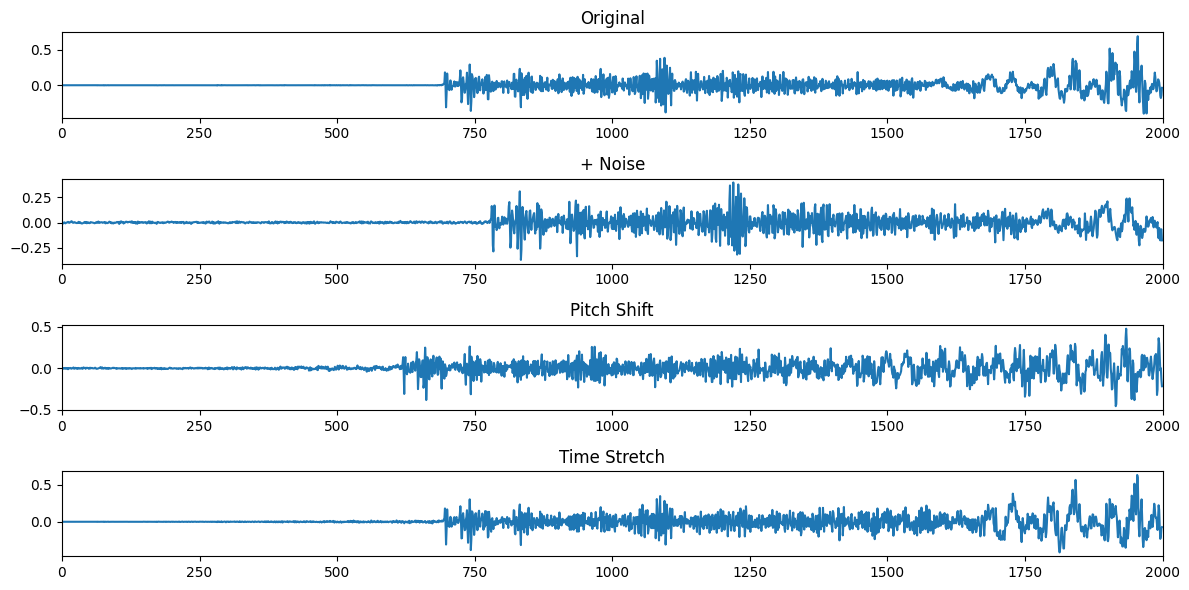

Saved fig04-data_augmentation.png


In [26]:
fig, axes = plt.subplots(4, 1, figsize=(12, 6))
names = ["Original", "+ Noise", "Pitch Shift", "Time Stretch"]
audios = [
    sample_audio,
    augment_audio(sample_audio),
    augment_audio(sample_audio),
    augment_audio(sample_audio),
]
for ax, name, aud in zip(axes, names, audios):
    ax.plot(aud[:2000])
    ax.set_title(name)
    ax.set_xlim(0, 2000)
plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig04-data_augmentation.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved fig04-data_augmentation.png')